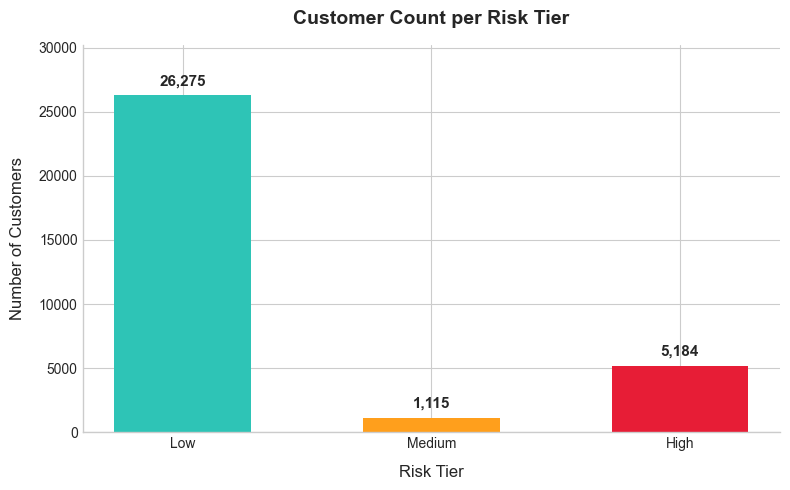

In [41]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('credit_risk_scored.csv')

tier_counts = df['risk_tier'].value_counts()
ordered_counts = tier_counts.reindex(['Low', 'Medium', 'High'])

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#2ec4b6', '#ff9f1c', '#e71d36']
bars = ax.bar(
    ordered_counts.index,
    ordered_counts.values,
    color=colors,
    width=0.55,
    edgecolor='none',
)

for bar in bars:
  height = bar.get_height()
  ax.annotate(
      f'{height:,}',
      xy=(bar.get_x() + bar.get_width() / 2, height),
      xytext=(0, 5),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=11,
      fontweight='bold',
  )

ax.set_title(
    'Customer Count per Risk Tier', fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Risk Tier', fontsize=12, labelpad=10)
ax.set_ylabel('Number of Customers', fontsize=12, labelpad=10)
ax.set_ylim(0, max(ordered_counts.values) * 1.15)  # Add breathing room on top
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig1_customer_count_per_risk_tier.png', dpi=300)
plt.show()

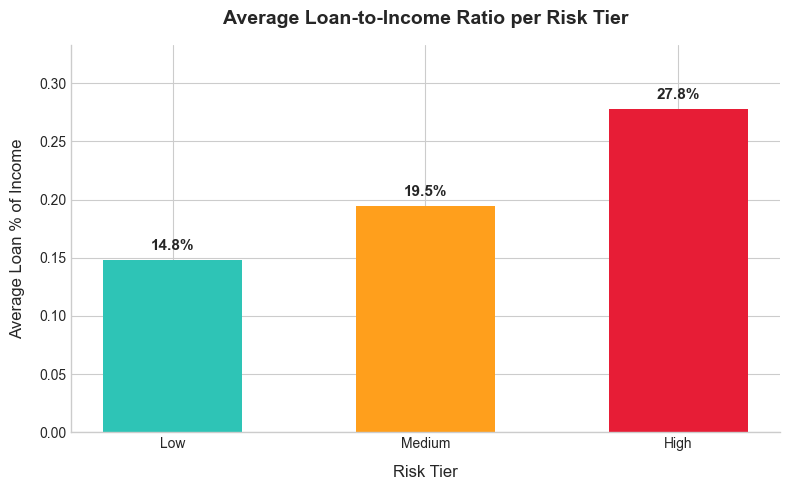

In [42]:
avg_percent = (
    df.groupby('risk_tier')['loan_percent_income']
    .mean()
    .reindex(['Low', 'Medium', 'High'])
)

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#2ec4b6', '#ff9f1c', '#e71d36']
bars = ax.bar(
    avg_percent.index,
    avg_percent.values,
    color=colors,
    width=0.55,
    edgecolor='none',
)

for bar in bars:
  height = bar.get_height()
  ax.annotate(
      f'{height * 100:.1f}%',
      xy=(bar.get_x() + bar.get_width() / 2, height),
      xytext=(0, 5),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=11,
      fontweight='bold',
  )

ax.set_title(
    'Average Loan-to-Income Ratio per Risk Tier',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
ax.set_xlabel('Risk Tier', fontsize=12, labelpad=10)
ax.set_ylabel('Average Loan % of Income', fontsize=12, labelpad=10)
ax.set_ylim(0, max(avg_percent.values) * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig2_avg_loan_percent_income_per_tier.png', dpi=300)
plt.show()

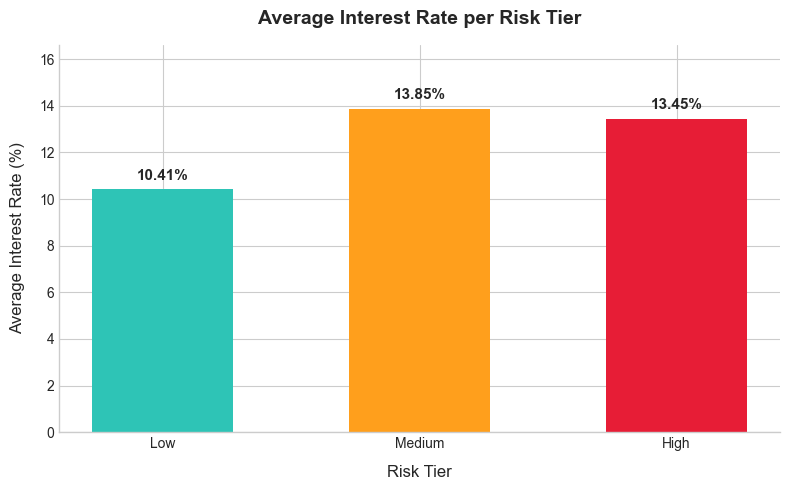

In [43]:
avg_int_rate = (
    df.groupby('risk_tier')['loan_int_rate']
    .mean()
    .reindex(['Low', 'Medium', 'High'])
)

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#2ec4b6', '#ff9f1c', '#e71d36']
bars = ax.bar(
    avg_int_rate.index,
    avg_int_rate.values,
    color=colors,
    width=0.55,
    edgecolor='none',
)

for bar in bars:
  height = bar.get_height()
  ax.annotate(
      f'{height:.2f}%',
      xy=(bar.get_x() + bar.get_width() / 2, height),
      xytext=(0, 5),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=11,
      fontweight='bold',
  )

ax.set_title(
    'Average Interest Rate per Risk Tier', fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Risk Tier', fontsize=12, labelpad=10)
ax.set_ylabel('Average Interest Rate (%)', fontsize=12, labelpad=10)
ax.set_ylim(0, max(avg_int_rate.values) * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig3_avg_interest_rate_per_tier.png', dpi=300)
plt.show()

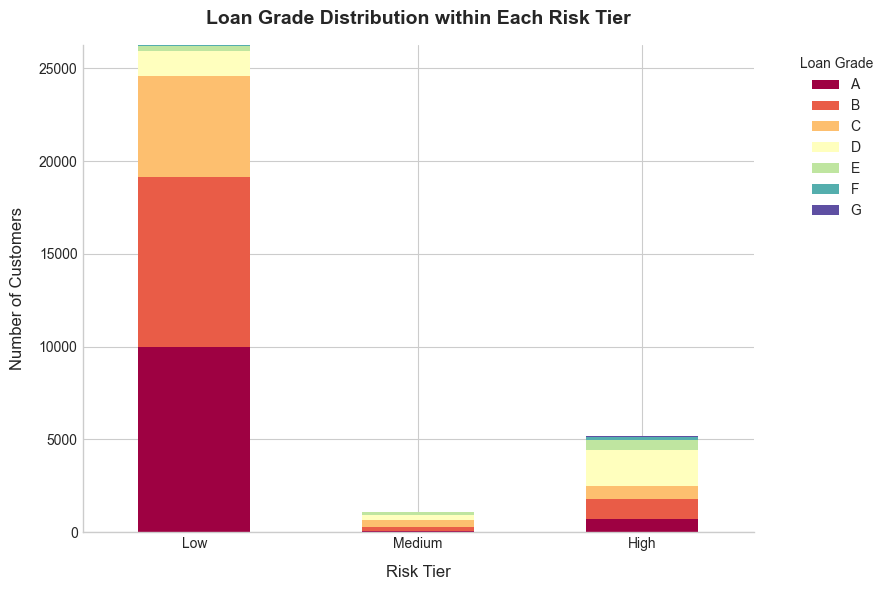

In [44]:
ct = pd.crosstab(df['risk_tier'], df['loan_grade']).reindex(
    ['Low', 'Medium', 'High']
)

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(9, 6))

ct.plot(
    kind='bar', stacked=True, ax=ax, colormap='Spectral', width=0.5, rot=0
)

ax.set_title(
    'Loan Grade Distribution within Each Risk Tier',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
ax.set_xlabel('Risk Tier', fontsize=12, labelpad=10)
ax.set_ylabel('Number of Customers', fontsize=12, labelpad=10)
ax.legend(title='Loan Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig4_loan_grade_distribution_per_risk_tier.png', dpi=300)
plt.show()

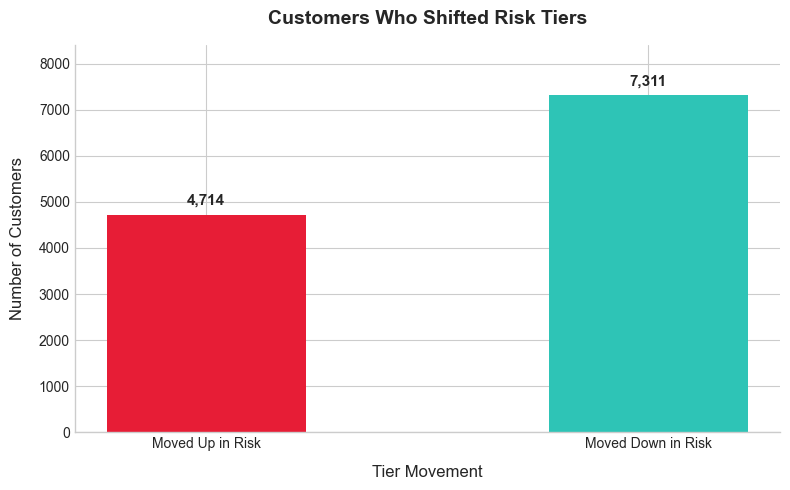

In [45]:
df = pd.read_csv('credit_risk_scored.csv')

grade_map = {
    'A': 'Low',
    'B': 'Low',
    'C': 'Medium',
    'D': 'Medium',
    'E': 'High',
    'F': 'High',
    'G': 'High',
}
df['initial_tier'] = df['loan_grade'].map(grade_map)

tier_rank = {'Low': 1, 'Medium': 2, 'High': 3}
df['initial_rank'] = df['initial_tier'].map(tier_rank)
df['final_rank'] = df['risk_tier'].map(tier_rank)

df['movement'] = 'No Change'
df.loc[df['final_rank'] > df['initial_rank'], 'movement'] = 'Moved Up in Risk'
df.loc[df['final_rank'] < df['initial_rank'], 'movement'] = (
    'Moved Down in Risk'
)

movement_counts = df['movement'].value_counts()
moved_df = movement_counts.reindex(['Moved Up in Risk', 'Moved Down in Risk'])

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#e71d36', '#2ec4b6']
bars = ax.bar(
    moved_df.index, moved_df.values, color=colors, width=0.45, edgecolor='none'
)

for bar in bars:
  height = bar.get_height()
  ax.annotate(
      f'{height:,}',
      xy=(bar.get_x() + bar.get_width() / 2, height),
      xytext=(0, 5),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=11,
      fontweight='bold',
  )

ax.set_title(
    'Customers Who Shifted Risk Tiers', fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Tier Movement', fontsize=12, labelpad=10)
ax.set_ylabel('Number of Customers', fontsize=12, labelpad=10)
ax.set_ylim(0, max(moved_df.values) * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig5_customers_moved_tiers.png', dpi=300)
plt.show()

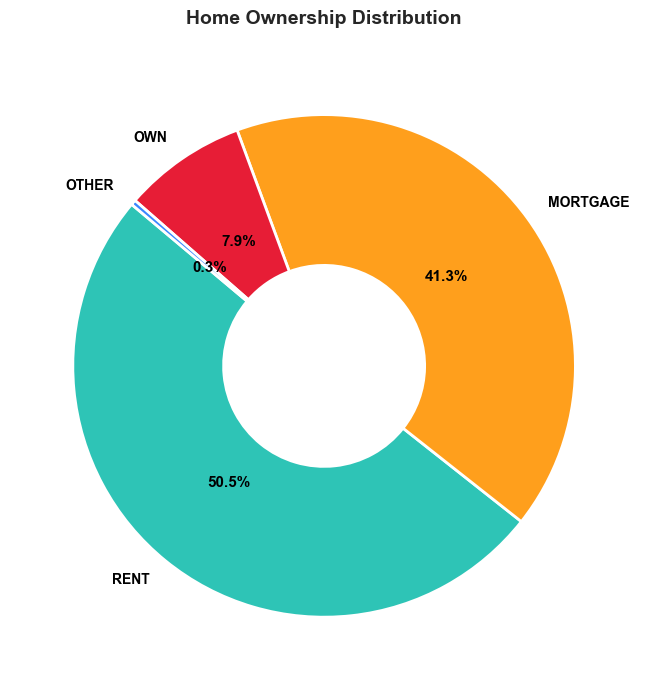

In [46]:
home_counts = df['person_home_ownership'].value_counts()

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(7, 7))

colors = ['#2ec4b6', '#ff9f1c', '#e71d36', '#3a86ff']

wedges, texts, autotexts = ax.pie(
    home_counts.values,
    labels=home_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors[: len(home_counts)],
    textprops=dict(color='black', fontweight='bold'),
    wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2),
)

plt.setp(autotexts, size=11, weight='bold')
ax.set_title(
    'Home Ownership Distribution', fontsize=14, fontweight='bold', pad=20
)

plt.tight_layout()
plt.savefig('fig6_home_ownership_distribution.png', dpi=300)
plt.show()

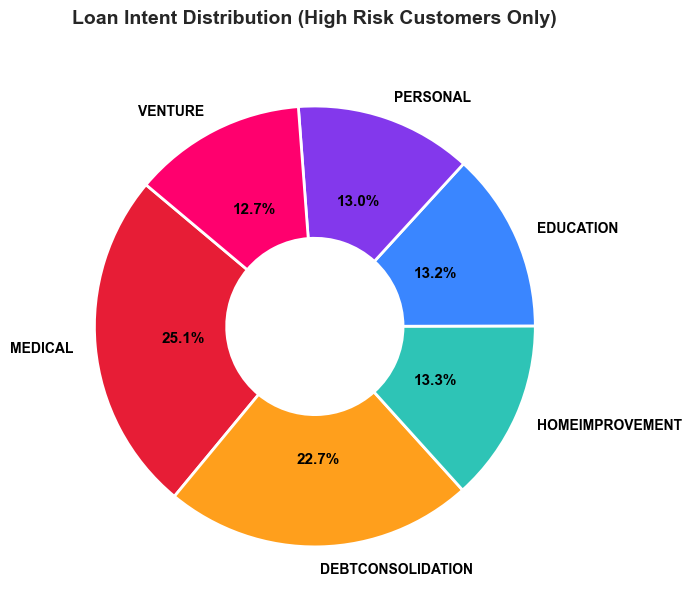

In [47]:
df = pd.read_csv('credit_risk_scored.csv')

high_risk_df = df[df['risk_tier'] == 'High']
intent_counts = high_risk_df['loan_intent'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))

colors = ['#e71d36', '#ff9f1c', '#2ec4b6', '#3a86ff', '#8338ec', '#ff006e']

wedges, texts, autotexts = ax.pie(
    intent_counts.values,
    labels=intent_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors[: len(intent_counts)],
    textprops=dict(color='black', fontweight='bold'),
    wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2),
)

plt.setp(autotexts, size=11, weight='bold')
ax.set_title(
    'Loan Intent Distribution (High Risk Customers Only)',
    fontsize=14,
    fontweight='bold',
    pad=20,
)

plt.tight_layout()
plt.savefig('fig7_loan_intent_high_risk.png', dpi=300)
plt.show()

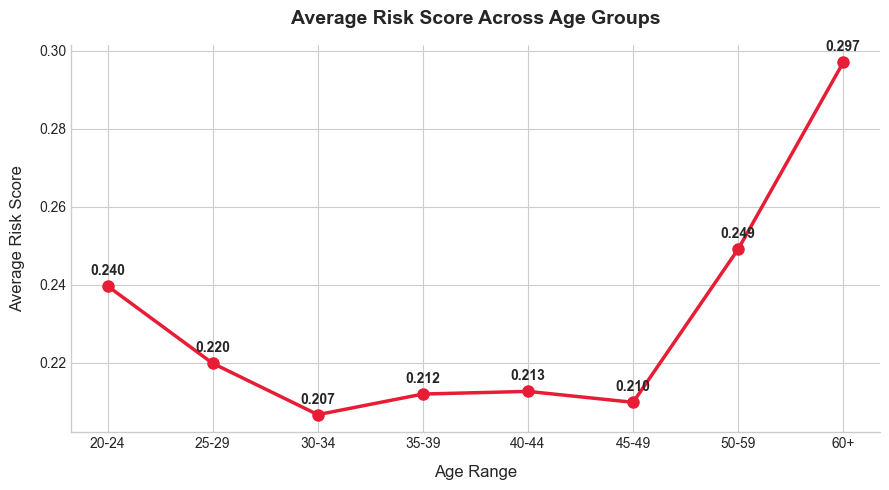

In [48]:
bins = [20, 25, 30, 35, 40, 45, 50, 60, 100]
labels = ['20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-59', '60+']

df['age_group'] = pd.cut(
    df['person_age'], bins=bins, labels=labels, right=False
)
age_risk = df.groupby('age_group', observed=False)['risk_score'].mean()

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    age_risk.index.astype(str),
    age_risk.values,
    marker='o',
    color='#e71d36',
    linewidth=2.5,
    markersize=8,
)

for i, txt in enumerate(age_risk.values):
  ax.annotate(
      f'{txt:.3f}',
      (age_risk.index.astype(str)[i], age_risk.values[i]),
      xytext=(0, 8),
      textcoords='offset points',
      ha='center',
      fontsize=10,
      fontweight='bold',
  )

ax.set_title(
    'Average Risk Score Across Age Groups', fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Age Range', fontsize=12, labelpad=10)
ax.set_ylabel('Average Risk Score', fontsize=12, labelpad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig8_avg_risk_score_across_age_groups.png', dpi=300)
plt.show()